<div style="padding: 30px; background: linear-gradient(135deg, #1e3a8a 0%, #3b82f6 100%); border-radius: 15px; text-align: center; color: white; box-shadow: 0 10px 20px rgba(0,0,0,0.2);">
    <h1 style="font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-size: 3em; margin-bottom: 0;">SmartRAD AI</h1>
    <hr style="border: 0; height: 2px; background: rgba(255,255,255,0.3); margin: 20px auto; width: 50%;">
    <p style="font-size: 1.2em; font-weight: 300;">Workflow Orchestration & Predictive Analytics Engine</p>
    <div style="margin-top: 20px; font-style: italic; opacity: 0.9;">
        Access your radiology Operational workflow and manage operations efficiently.
    </div>
</div>


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import joblib

In [2]:
# LOAD DATA
df = pd.read_csv('/kaggle/input/datasets/programmerx3d/x-ray-operational-workflow-optimization/historical_xray_data_v3.csv')

df.head()

,exam_type,modality_type,request_hour,day_of_week,is_urgent,room_load_at_request,technician_experience,patient_age_group,body_part,base_duration,actual_duration
0,Shoulder,CR,6,6,0,4.0,9.0,Adult,Abdomen,13,23
1,Abdomen,DX,20,3,0,6.0,NaN,Elderly,Upper_Limb,15,22
2,Hand,DX,11,2,0,16.0,4.0,Adult,Thorax,7,20
3,Shoulder,CR,17,6,0,NaN,5.0,Adult,Upper_Limb,13,33
4,Spine,DX,13,5,0,17.0,18.0,Elderly,Abdomen,18,40


In [3]:
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

Dataset Shape: (4000, 11)

Missing Values:
 exam_type                  0
modality_type              0
request_hour               0
day_of_week                0
is_urgent                  0
room_load_at_request     240
technician_experience    280
patient_age_group          0
body_part                  0
base_duration              0
actual_duration            0
dtype: int64


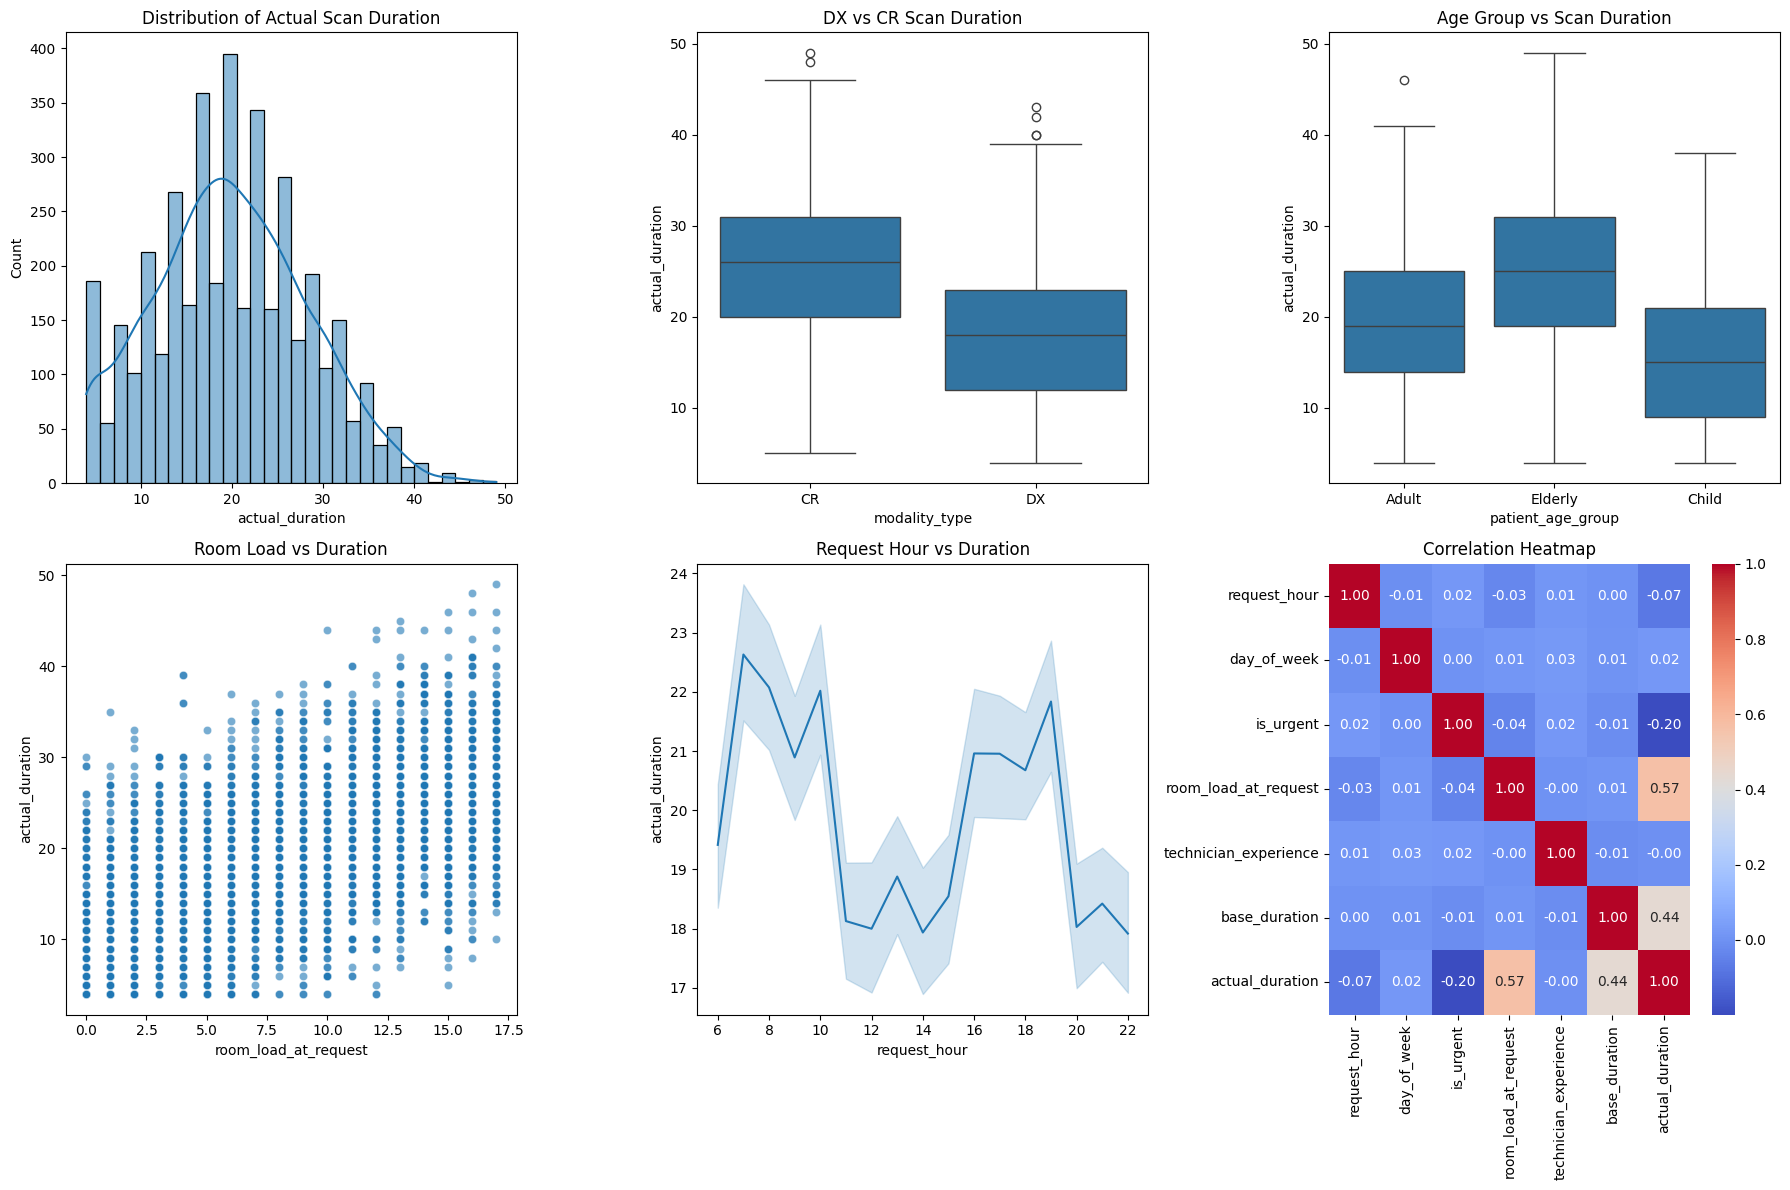

In [4]:
# EDA & PLOTS
plt.figure(figsize=(18, 12))

# 1. Distribution of Target
plt.subplot(2, 3, 1)
sns.histplot(df['actual_duration'], kde=True, bins=30)
plt.title('Distribution of Actual Scan Duration')

# 2. Modality Type vs Duration
plt.subplot(2, 3, 2)
sns.boxplot(x='modality_type', y='actual_duration', data=df)
plt.title('DX vs CR Scan Duration')

# 3. Patient Age Group vs Duration
plt.subplot(2, 3, 3)
sns.boxplot(x='patient_age_group', y='actual_duration', data=df)
plt.title('Age Group vs Scan Duration')

# 4. Room Load vs Duration
plt.subplot(2, 3, 4)
sns.scatterplot(x='room_load_at_request', y='actual_duration', data=df, alpha=0.6)
plt.title('Room Load vs Duration')

# 5. Request Hour vs Duration
plt.subplot(2, 3, 5)
sns.lineplot(x='request_hour', y='actual_duration', data=df)
plt.title('Request Hour vs Duration')

# 6. Correlation Heatmap
plt.subplot(2, 3, 6)
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')

plt.tight_layout()
plt.show()

In [5]:
# PREPROCESSING
df['technician_experience'] = df['technician_experience'].fillna(df['technician_experience'].median())
df['room_load_at_request'] = df['room_load_at_request'].fillna(df['room_load_at_request'].mean())
df['patient_age_group'] = df['patient_age_group'].fillna(df['patient_age_group'].mode()[0])

# Label Encoding
categorical_cols = ['exam_type', 'modality_type', 'patient_age_group', 'body_part']
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

In [6]:
# Features and Target
X = df.drop(['actual_duration'], axis=1)
y = df['actual_duration']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
# MODEL TRAINING
# Random Forest
rf = RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [8]:
rf_pred = rf.predict(X_test)

In [9]:
# XGBoost
xgb_model = xgb.XGBRegressor(n_estimators=400, learning_rate=0.08, max_depth=10, random_state=42, eval_metric='rmse')
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.08, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

In [10]:
xgb_pred = xgb_model.predict(X_test)

In [11]:
# Hybrid
hybrid_pred = (rf_pred + xgb_pred) / 2

In [12]:
# EVALUATION
def evaluate(name, pred):
    print(f"\n=== {name} Performance ===")
    print(f"MAE  : {mean_absolute_error(y_test, pred):.2f} minutes")
    print(f"RMSE : {np.sqrt(mean_squared_error(y_test, pred)):.2f} minutes")
    print(f"R²   : {r2_score(y_test, pred):.4f}")

In [13]:
evaluate("Random Forest", rf_pred)



=== Random Forest Performance ===
MAE  : 3.34 minutes
RMSE : 4.25 minutes
R²   : 0.7233


In [14]:
evaluate("XGBoost", xgb_pred)


=== XGBoost Performance ===
MAE  : 3.38 minutes
RMSE : 4.32 minutes
R²   : 0.7137


In [15]:
evaluate("Hybrid (RF + XGB)", hybrid_pred)


=== Hybrid (RF + XGB) Performance ===
MAE  : 3.30 minutes
RMSE : 4.21 minutes
R²   : 0.7277


In [16]:
# Feature Importance
importances = pd.Series(xgb_model.feature_importances_, index=X.columns)
print("\nTop 10 Important Features:\n", importances.sort_values(ascending=False).head(10))


Top 10 Important Features:
 modality_type            0.274330
base_duration            0.272549
patient_age_group        0.175602
room_load_at_request     0.137557
is_urgent                0.065741
request_hour             0.017849
body_part                0.015183
technician_experience    0.014757
exam_type                0.013635
day_of_week              0.012798
dtype: float32


In [22]:
# Saving ouput
joblib.dump(rf, 'smartrad_rfR_model.pkl')
joblib.dump(encoders, 'label_encoders.pkl')
print("\nModels and encoders saved successfully!")


Models and encoders saved successfully!


In [29]:
# Testing the model results with dummy data if they perform well or not

# Load model and encoders
model = joblib.load('smartrad_rfR_model.pkl')
encoders = joblib.load('label_encoders.pkl')

# 10 DUMMY TEST CASES
data = {
    'exam_type': ['Chest', 'Knee', 'Spine', 'Chest', 'Hand', 'Abdomen', 'Shoulder', 'Pelvis', 'Knee', 'Chest'],
    'modality_type': ['DX', 'CR', 'DX', 'DX', 'CR', 'DX', 'DX', 'CR', 'DX', 'CR'],
    'request_hour': [9, 14, 8, 18, 11, 10, 16, 7, 13, 22],
    'day_of_week': [1, 2, 0, 4, 5, 3, 6, 1, 2, 0],
    'is_urgent': [0, 1, 0, 1, 0, 0, 1, 0, 0, 1],
    'room_load_at_request': [3, 12, 8, 15, 4, 7, 11, 9, 2, 14],
    'technician_experience': [8, 3, 12, 5, 15, 7, 4, 10, 6, 2],
    'patient_age_group': ['Adult', 'Elderly', 'Child', 'Elderly', 'Adult', 'Adult', 'Elderly', 'Child', 'Adult', 'Elderly'],
    'body_part': ['Thorax', 'Lower_Limb', 'Spine', 'Thorax', 'Upper_Limb', 'Abdomen', 'Upper_Limb', 'Lower_Limb', 'Lower_Limb', 'Thorax']
}

df_test = pd.DataFrame(data)

# ADD base_duration
base = {'Chest':8, 'Knee':12, 'Spine':18, 'Abdomen':15, 'Hand':7, 'Pelvis':14, 'Shoulder':13}
df_test['base_duration'] = df_test['exam_type'].map(base)

# Preprocessing
df_test['technician_experience'] = df_test['technician_experience'].fillna(df_test['technician_experience'].median())
df_test['room_load_at_request'] = df_test['room_load_at_request'].fillna(df_test['room_load_at_request'].mean())

# Applying Label Encoding
for col in encoders.keys():
    if col in df_test.columns:
        df_test[col] = encoders[col].transform(df_test[col].astype(str))

# Predictions
predictions = model.predict(df_test)

df_test['predicted_duration_minutes'] = predictions.round(1)

# Display Results
print("\n" + "="*70)
print("MODEL PREDICTIONS ON 10 DUMMY CASES")
print("="*70)
display_cols = ['exam_type', 'modality_type', 'patient_age_group', 'room_load_at_request', 
                'is_urgent', 'base_duration', 'predicted_duration_minutes']
print(df_test[display_cols])


MODEL PREDICTIONS ON 10 DUMMY CASES
   exam_type  modality_type  patient_age_group  room_load_at_request  \
0          1              1                  0                     3   
1          3              0                  2                    12   
2          6              1                  1                     8   
3          1              1                  2                    15   
4          2              0                  0                     4   
5          0              1                  0                     7   
6          5              1                  2                    11   
7          4              0                  1                     9   
8          3              1                  0                     2   
9          1              0                  2                    14   

   is_urgent  base_duration  predicted_duration_minutes  
0          0              8                         9.4  
1          1             12                        31.

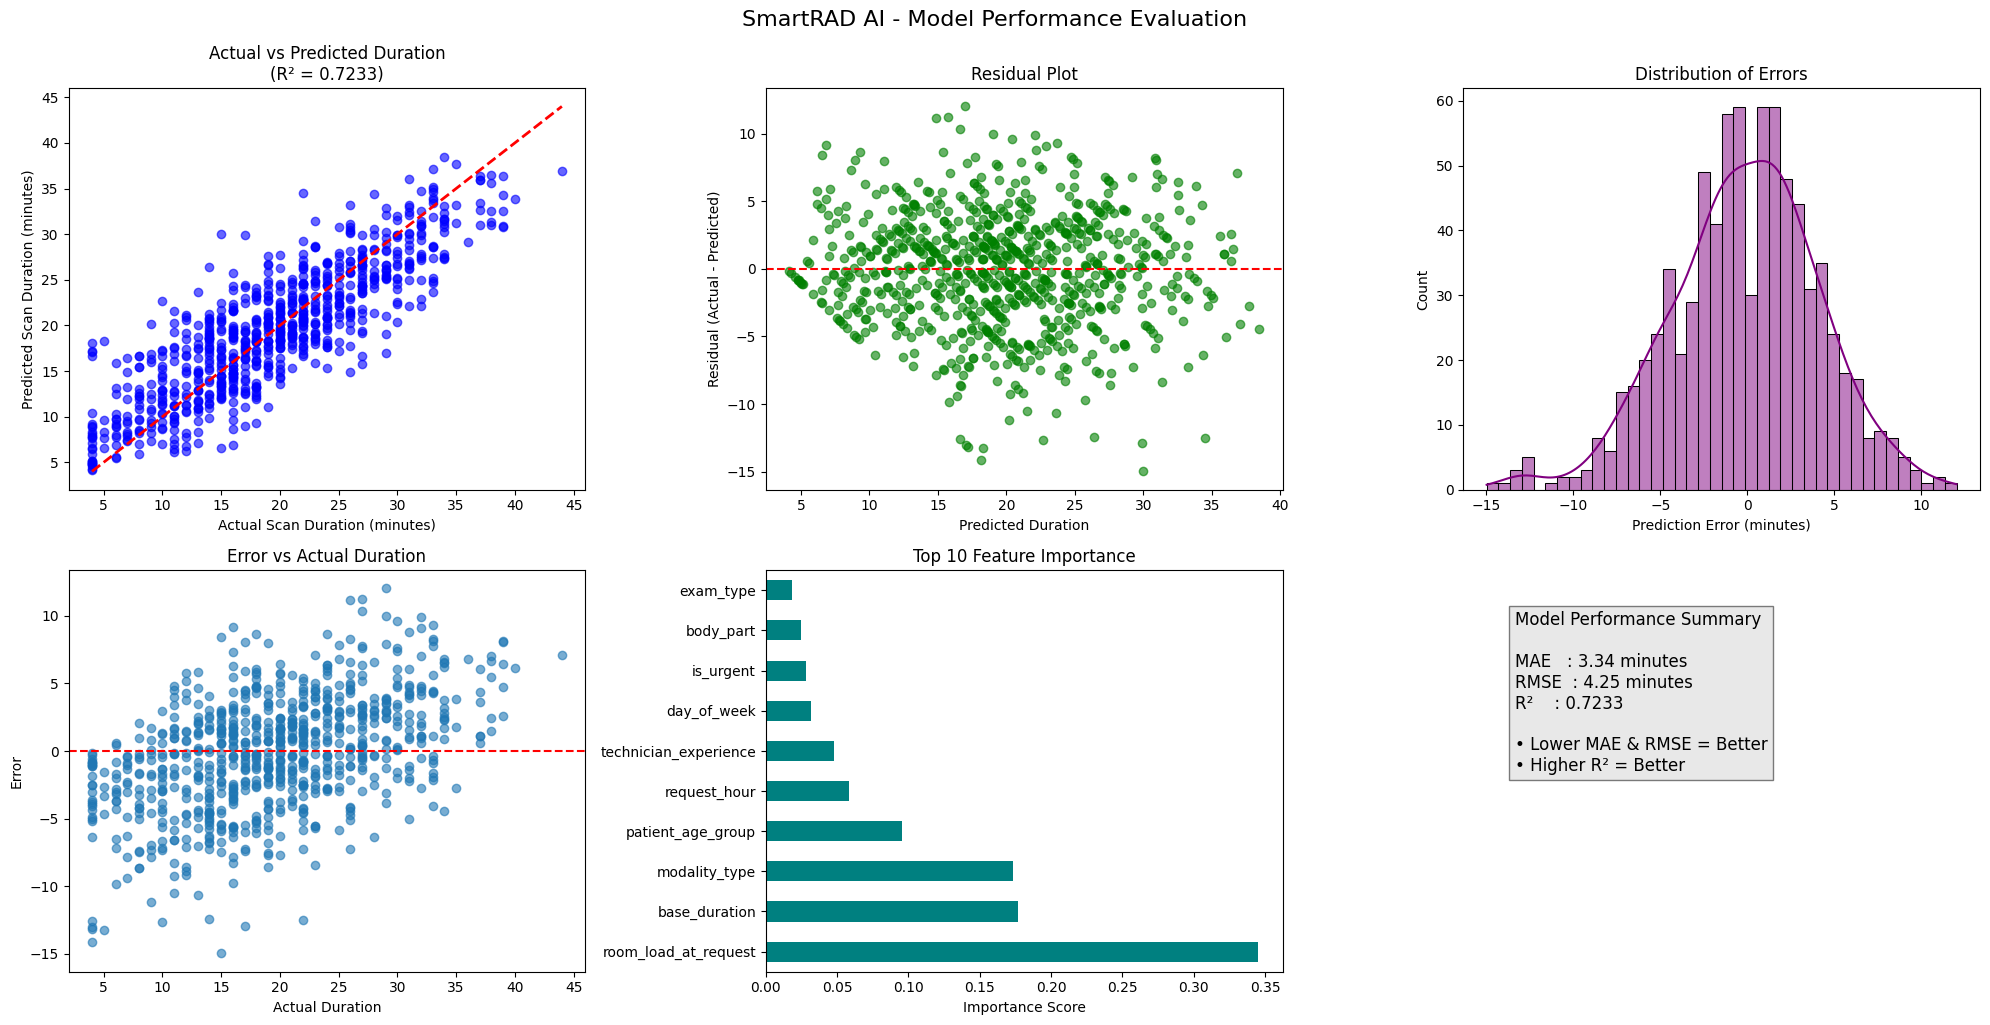

In [32]:
# Evaluation Graphs

# Creating results dataframe
results = pd.DataFrame({
    'Actual': y_true,
    'Predicted': y_pred,
    'Error': y_true - y_pred
}).reset_index(drop=True)

# Plots
plt.figure(figsize=(20, 10))

# 1. Actual vs Predicted (Most Important)
plt.subplot(2, 3, 1)
plt.scatter(results['Actual'], results['Predicted'], alpha=0.6, color='blue')
plt.plot([results['Actual'].min(), results['Actual'].max()], 
         [results['Actual'].min(), results['Actual'].max()], 'r--', lw=2)
plt.xlabel('Actual Scan Duration (minutes)')
plt.ylabel('Predicted Scan Duration (minutes)')
plt.title('Actual vs Predicted Duration\n(R² = {:.4f})'.format(r2_score(y_true, y_pred)))

# 2. Residual Plot
plt.subplot(2, 3, 2)
plt.scatter(results['Predicted'], results['Error'], alpha=0.6, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Duration')
plt.ylabel('Residual (Actual - Predicted)')
plt.title('Residual Plot')

# 3. Error Distribution
plt.subplot(2, 3, 3)
sns.histplot(results['Error'], kde=True, bins=40, color='purple')
plt.xlabel('Prediction Error (minutes)')
plt.title('Distribution of Errors')

# 4. Error vs Actual Value
plt.subplot(2, 3, 4)
plt.scatter(results['Actual'], results['Error'], alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Actual Duration')
plt.ylabel('Error')
plt.title('Error vs Actual Duration')

# 5. Feature Importance (Clean)
plt.subplot(2, 3, 5)
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Feature Importance')
plt.xlabel('Importance Score')

# 6. Performance Metrics Text Box
plt.subplot(2, 3, 6)
plt.axis('off')
metrics_text = f"""Model Performance Summary

MAE   : {mean_absolute_error(y_true, y_pred):.2f} minutes
RMSE  : {np.sqrt(mean_squared_error(y_true, y_pred)):.2f} minutes
R²    : {r2_score(y_true, y_pred):.4f}

• Lower MAE & RMSE = Better
• Higher R² = Better"""
plt.text(0.1, 0.5, metrics_text, fontsize=12, bbox=dict(facecolor='lightgray', alpha=0.5))

plt.tight_layout()
plt.suptitle('SmartRAD AI - Model Performance Evaluation', fontsize=16, y=1.02)
plt.show()

<div style="margin-top: 50px; padding: 40px; text-align: center; border-top: 1px solid #e2e8f0;">
    <div style="font-size: 40px; color: #0799f4ff; margin-bottom: -10px;">“</div>
    <p style="font-family: 'Georgia', serif; font-size: 1.5em; font-style: italic; color: #053577ff; line-height: 1.6;">
        Intelligence is not just about predicting the future,<br> 
        but about optimizing the present to save lives.
    </p>
    <div style="font-size: 40px; color: #657998ff; margin-top: -25px; margin-left: 300px;">”</div>
    <p style="margin-top: 10px; font-weight: bold; color: #167eedff; letter-spacing: 2px;">SMARTRAD AI • 2026</p>
</div>